In [22]:
import torch
import tiktoken

with open("../datasets/raw_text.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
#print(raw_text[:1000])
raw_text = raw_text[:50000]
print(len(raw_text))


50000


# Datenvorbereitung

Der in Lab 2 erstellte raw_text wird für das Training aufgeteilt. 
90% der Daten werden für das Training verwendet, die verbleibenden 
10% dienen als Validierungsdatensatz zur Überprüfung der Generalisierung 
des Modells auf ungesehene Daten.

In [23]:
import sys
sys.path.append('.')
from lab2 import GPTDatasetV1, create_dataloader_v1


train_ratio = 0.9
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

print(f"Training: {len(train_data)} Zeichen")
print(f"Validierung: {len(val_data)} Zeichen")

Training: 45000 Zeichen
Validierung: 5000 Zeichen


matplotlib version: 3.10.9
torch version: 2.12.0
tiktoken version: 0.13.0
Layer Output: tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>) 

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>) 


Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mittelwert:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Varianz:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
Original Batch:
 tensor([[ 0.3374, -0.1778, -0.3035, -0.5880,  0.3486,  0.6603, -0.2196, -0.3792],
        [ 0.7671, -1.1925,  0.6984, -1.4097,  0.1794,  1.8951,  0.4954,  0.2692],
        [-0.0770, -1.0205, -0.1690,  0.9178,  1.5810,  1.3010,  1.2753, -0.2010],
        [ 0

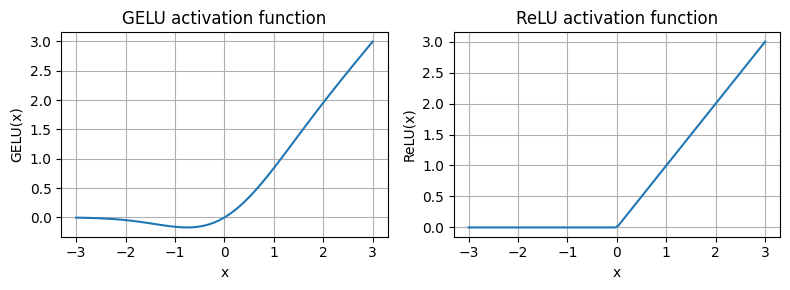

Gradienten ohne Shortcut layersizes 1 [3, 3, 3, 3, 3, 1]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 0.0004458633775357157
layers.1.0.weight Gradientenmittelwert: 0.00015799672110006213
layers.2.0.weight Gradientenmittelwert: 0.0016104783862829208
layers.3.0.weight Gradientenmittelwert: 0.0003816350654233247
layers.4.0.weight Gradientenmittelwert: 0.002110143890604377

Sample Input 1: tensor([[ 1.,  0., -1.]])
layers.0.0.weight Gradientenmittelwert: 0.00020173587836325169
layers.1.0.weight Gradientenmittelwert: 0.0001201116101583466
layers.2.0.weight Gradientenmittelwert: 0.0007152041071094573
layers.3.0.weight Gradientenmittelwert: 0.0013988735154271126
layers.4.0.weight Gradientenmittelwert: 0.005049645435065031

Gradienten ohne Shortcut layersizes 2 [3, 3, 3, 3, 3, 3]:

Sample Input 0: tensor([[18.,  4.,  2.]])
layers.0.0.weight Gradientenmittelwert: 0.0013512182049453259
layers.1.0.weight Gradientenmittelwert: 0.00053369504166767
layers.2.0.w

In [24]:
#import sys
#sys.path.append('.')

#from Abgabe.archive.lab4 import GPT_CONFIG, GPTModel, generate_text_simple
from lab4 import GPT_CONFIG, GPTModel, generate_text_simple


# DataLoader

Der DataLoader aus Lab 2 wird für Training und Validierung konfiguriert. 
Jeder Batch enthält 2 Sequenzen mit je 1024 Tokens, entsprechend der 
konfigurierten context_length. Der Trainingsdatensatz wird mit shuffle=True 
zufällig gemischt um Überanpassung an die Reihenfolge der Daten zu vermeiden, 
während der Validierungsdatensatz sequenziell verarbeitet wird. 
drop_last=True stellt sicher dass unvollständige Batches beim Training 
verworfen werden.

In [25]:

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break

print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train loader:
torch.Size([2, 1024]) torch.Size([2, 1024])
Validation loader:
torch.Size([1, 1024]) torch.Size([1, 1024])


# Verlustfunktion

Implementierung der Verlustfunktionen zur Bewertung der Modellleistung.

calc_loss_batch berechnet den Cross-Entropy Loss für einen einzelnen 
Batch. Der Cross-Entropy Loss misst die Abweichung zwischen den 
vorhergesagten Token-Wahrscheinlichkeiten und den tatsächlichen 
Ziel-Tokens. Je niedriger der Loss desto besser die Vorhersagen des Modells.

calc_loss_loader berechnet den durchschnittlichen Loss über mehrere 
Batches eines DataLoaders und ermöglicht so eine Gesamtbewertung der 
Modellleistung auf dem Trainings- oder Validierungsdatensatz.

In [26]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    num_batches = num_batches or len(data_loader)
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
    return total_loss / num_batches

# Device Konfiguration und initialer Loss

Das Modell wird auf dem verfügbaren Gerät initialisiert. Dabei wird 
bevorzugt eine CUDA GPU verwendet, gefolgt von Apple MPS für M-Series 
Prozessoren und CPU als Fallback.

Der initiale Loss wird vor dem Training berechnet um einen Referenzwert 
zu erhalten. Da das Modell zufällig initialisiert ist, entspricht der 
erwartete Loss dem negativen Logarithmus der reziproken Vokabulargröße 
ln(100277) ≈ 11.5. Ein höherer initialer Loss deutet auf eine zufällige 
Gewichtsinitialisierung hin, was das erwartete Verhalten eines 
untrainierten Modells ist.

In [27]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model = GPTModel(GPT_CONFIG)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 11.702503363291422
Validation loss: 11.665536880493164


# Hilfsfunktionen zur Textkonvertierung

text_to_token_ids kodiert einen Text mittels tiktoken in Token IDs 
und fügt eine Batch-Dimension hinzu, da das Modell einen 2D Tensor 
als Eingabe erwartet.

token_ids_to_text dekodiert Token IDs zurück in lesbaren Text 
indem die Batch-Dimension entfernt und die IDs mittels tiktoken 
in Zeichenketten umgewandelt werden.

In [28]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

# Evaluierungs- und Sampling Funktionen

evaluate_model berechnet den Loss auf Trainings- und Validierungsdaten 
während des Trainings. Das Modell wird dabei in den Evaluierungsmodus 
versetzt um Dropout zu deaktivieren, und anschließend wieder in den 
Trainingsmodus zurückgesetzt.

generate_and_print_sample generiert nach jeder Trainingsepoche einen 
Beispieltext um den Lernfortschritt des Modells qualitativ zu beurteilen. 
Der generierte Text zeigt wie gut das Modell bereits sinnvolle 
Rezeptstrukturen erlernt hat.

In [29]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=text_to_token_ids(start_context, tokenizer).to(device),
            max_new_tokens=50,
            context_size=model.pos_emb.weight.shape[0]
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


# Live Visualisierung des Trainingsverlaufs

Der Live Plot aktualisiert sich nach jedem Evaluierungsschritt während 
des Trainings und zeigt den Verlauf von Training Loss und Validation Loss. 
clear_output löscht dabei die vorherige Ausgabe um eine animierte 
Darstellung zu erzeugen. So kann der Lernfortschritt des Modells in 
Echtzeit beobachtet werden und ein frühzeitiges Overfitting erkannt werden.


In [30]:

from IPython.display import clear_output
import matplotlib.pyplot as plt

def plot_losses_live(train_losses, val_losses, tokens_seen):
    clear_output(wait=True)
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss")
    ax1.legend()
    plt.tight_layout()
    plt.show()
    


# Training

Implementierung der Trainingsschleife mittels train_model_simple. 
In jeder Iteration wird der Loss berechnet, die Gradienten durch 
loss.backward() propagiert und die Gewichte durch den AdamW Optimizer 
aktualisiert. AdamW wird gegenüber dem klassischen SGD bevorzugt da 
er adaptive Lernraten verwendet und Weight Decay zur Regularisierung 
integriert.

Alle eval_freq Schritte wird der aktuelle Loss auf Trainings- und 
Validierungsdaten berechnet und der Live Plot aktualisiert. Nach jeder 
Epoche wird ein Beispieltext generiert um den qualitativen Lernfortschritt 
zu beurteilen.

## Overfitting Analyse

Nach dem Training wird überprüft ob der Validation Loss am Ende höher 
ist als zu Beginn. Ein steigender Validation Loss bei sinkendem Training 
Loss deutet auf Overfitting hin, das Modell hat die Trainingsdaten 
auswendig gelernt anstatt allgemeine Sprachmuster zu erkennen. Bei einem 
kleinen Datensatz wie hier ist Overfitting ein erwartetes Verhalten.

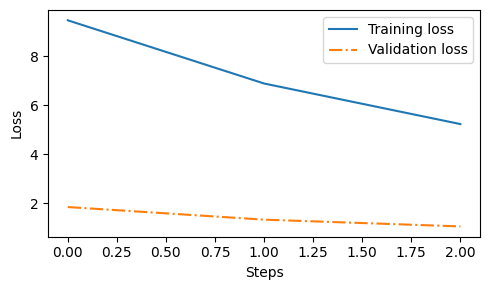

Recepie: 1 1/2an. 1 1 1 1/2an. 1/2an. 1/2an. 1 1 1 1 1 1 1 1 1


In [31]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
                plot_losses_live(train_losses, val_losses, tokens_seen)

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

tokenizer = tiktoken.get_encoding("gpt2")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Recepie:", tokenizer=tokenizer
)

if __name__ == '__main':
        
    if val_losses[-1] > val_losses[0]:
        print("Overfitting erkannt!")
        print(f"Validation Loss am Anfang: {val_losses[0]:.3f}")
        print(f"Validation Loss am Ende:   {val_losses[-1]:.3f}")
    else:
        print("Kein Overfitting")


# Erweiterte Textgenerierung

Implementierung der generate Funktion als Erweiterung von 
generate_text_simple mit zwei zusätzlichen Dekodierungsstrategien.

## Top-k Sampling

Top-k Sampling beschränkt die Auswahl des nächsten Tokens auf die 
k wahrscheinlichsten Kandidaten. Alle anderen Tokens werden auf 
-inf gesetzt und nach der Softmax-Funktion zu 0. Dies verhindert 
dass unwahrscheinliche Tokens ausgewählt werden.

## Temperature Scaling

Temperature skaliert die Logits vor der Softmax-Funktion. Eine niedrige 
Temperature macht die Verteilung schärfer und das Modell wählt 
konservativer das wahrscheinlichste Token. Eine hohe Temperature 
verteilt die Wahrscheinlichkeiten gleichmäßiger und erzeugt 
kreativeren aber weniger kohärenten Text. Bei temperature=0.0 
wird Greedy Decoding verwendet wie in generate_text_simple.

In [32]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# Vergleich verschiedener Temperaturen

Der Vergleich zeigt den Einfluss der Temperature auf den generierten Text. 
Bei temperature=0.0 wird stets das wahrscheinlichste Token gewählt, 
was zu deterministischem aber repetitivem Text führt. Mit steigender 
Temperature wird die Ausgabe zunehmend variabler und kreativer, 
jedoch auf Kosten der sprachlichen Kohärenz. temperature=1.4 erzeugt 
den kreativsten Text, kann jedoch auch zu weniger sinnvollen 
Wortfolgen führen.

In [33]:
temperatures = [0.0, 0.5, 1.4]

for temp in temperatures:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids("Recepie:", tokenizer).to(device),
        max_new_tokens=20,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=temp
    )
    print(temp)
    print(token_ids_to_text(token_ids, tokenizer))

0.0
Recepie: 1 1/2an. 1 1 1 1/2an.
0.5
Recepie: 1 1 1 1an. 1 1 1 1 1
1.4
Recepie: 1 1 admissionsay .' Apr.'achelorayay Bodyay  all 4 


# Generierung verschiedener Rezepte

Das trainierte Modell wird mit verschiedenen Rezeptanfängen getestet 
um die Generalisierungsfähigkeit zu evaluieren. Jeder Kontext gibt 
einen Rezepttitel und den Beginn der Zutatenliste vor, woraufhin 
das Modell die Fortsetzung generiert.

Da das Modell auf Rezeptdaten trainiert wurde, sollte es grundlegende 
Rezeptstrukturen wie Zutatenmengen und Zubereitungsschritte erkennen. 
Die Qualität der generierten Rezepte hängt dabei direkt von der 
Trainingsdatenmenge und der Anzahl der Trainingsepochen ab. Bei einem 
kleinen Datensatz und wenigen Epochen sind die Ausgaben noch 
inkohärent, zeigen jedoch bereits grundlegende Rezeptmuster.

In [34]:
contexts = [
    "Recepie: Chocolate Cake\nIngredients:",
    "Recepie: Pizza\nIngredients:",
    "Recepie: Soup\nIngredients:",
]

for context in contexts:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(context, tokenizer).to(device),
        max_new_tokens=100,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=1.4
    )
    print(f"\nStart: {context}")
    print(f"Generated: {token_ids_to_text(token_ids, tokenizer)}")


Start: Recepie: Chocolate Cake
Ingredients:


KeyError: 'Invalid token for decoding: 53174'

# Textgenerierung mit optimierten Parametern

Abschließende Textgenerierung mit den optimierten Dekodierungsparametern 
top_k=25 und temperature=1.4. Diese Kombination aus Top-k Sampling 
und Temperature Scaling erzeugt einen ausgewogenen Text der sowohl 
kohärent als auch kreativ ist. Der generierte Text zeigt den 
aktuellen Lernstand des Modells nach dem Training auf dem Rezeptdatensatz.

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Recepie: 1/2 c..,. sugar,.,.,
Directions:


In [ ]:
import os

if not os.path.exists("../datasets/model_and_optimizer.pth"):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    },
    "../datasets/model_and_optimizer.pth"
    )
    print("Modell gespeichert!")
else:
    print("Modell bereits gespeichert.")

Modell bereits gespeichert.
